# Calibración de modelos
**Aprendizaje de Máquina - CEIA - FIUBA**

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.calibration import CalibrationDisplay, calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, log_loss, accuracy_score, f1_score, mean_absolute_error, r2_score, root_mean_squared_error, mean_absolute_percentage_error, fbeta_score, make_scorer, recall_score, precision_score

from sklearn.pipeline import make_pipeline


# Metricas

In [50]:
decision_tree_tuned = joblib.load('../models/decision_tree_tuned.pkl')
random_forest_tuned = joblib.load('../models/random_forest_tuned.pkl')
xgboost_tuned = joblib.load('../models/xgboost_tuned.pkl')
random_forest_classifier_op_tuned = joblib.load('../models/random_forest_classifier_op_tuned.pkl')
data = joblib.load('../data/processed_data.pkl')
columns = data['feature_names']
X_train = pd.DataFrame(data['X_train'], columns=columns)
X_test = pd.DataFrame(data['X_test'], columns=columns)
y_train = data['y_train']
y_test = data['y_test']

In [ ]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train, y_train)

pred_gnb = gnb.predict(X_test)
probs_gnb = gnb.predict_proba(X_test)[:,1]

# Métricas
acc_gnb = accuracy_score(y_test, pred_gnb)

print(f"Accuracy: {acc_gnb:.3f}")

Accuracy: 0.376


Brier Score:  0.576


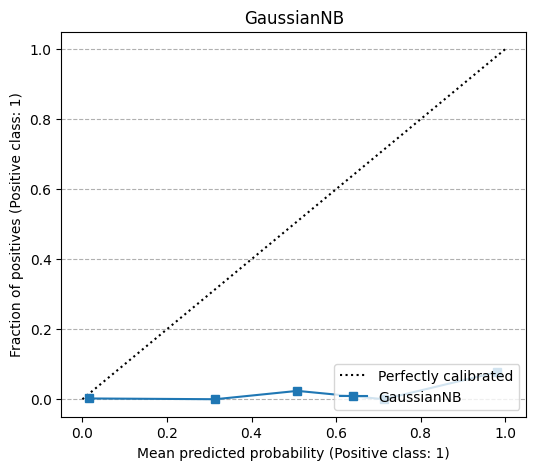

In [4]:
brier_gnb = brier_score_loss(y_test, probs_gnb)

print(f"Brier Score:  {brier_gnb:.3f}")

fig, ax = plt.subplots(figsize=(6, 5))
CalibrationDisplay.from_estimator(gnb, X_test, y_test, ax=ax)
ax.grid(axis='y', ls='--')
plt.title("GaussianNB")
plt.show()

GaussianNB muestra un comportamiento típico de modelos mal calibrados:

- Predice probabilidades muy extremas cercanas a 0
- Su curva sin calibrar queda lejos de la diagonal ideal.

### Calibracion

In [51]:
model = random_forest_classifier_op_tuned

In [52]:
# Ada + calibración Platt Scaling (sigmoid)
rf_platt = CalibratedClassifierCV(model, method='sigmoid', cv=5)
rf_platt.fit(X_train, y_train)

CalibratedClassifierCV(cv=5,
                       estimator=RandomForestClassifier(class_weight='balanced',
                                                        criterion='entropy',
                                                        max_depth=28,
                                                        min_samples_leaf=19,
                                                        n_estimators=206,
                                                        random_state=42))

In [53]:
# Ada + calibración Isotonic
rf_iso = CalibratedClassifierCV(model, method='isotonic', cv=5)
rf_iso.fit(X_train, y_train)

CalibratedClassifierCV(cv=5,
                       estimator=RandomForestClassifier(class_weight='balanced',
                                                        criterion='entropy',
                                                        max_depth=28,
                                                        min_samples_leaf=19,
                                                        n_estimators=206,
                                                        random_state=42),
                       method='isotonic')

Obtengamos ahora las métricas de calibración para los modelos, obteniendo primero las predicciones de probabilidad.

In [54]:
probs_rf = random_forest_classifier_op_tuned.predict_proba(X_test)[:, 1]
probs_platt = rf_platt.predict_proba(X_test)[:, 1]
probs_iso = rf_iso.predict_proba(X_test)[:, 1]

c:\Users\cristian.aballay\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


#### Probabilidad original vs calibrada

Grafiquemos las predicciones originales vs las calibradas:

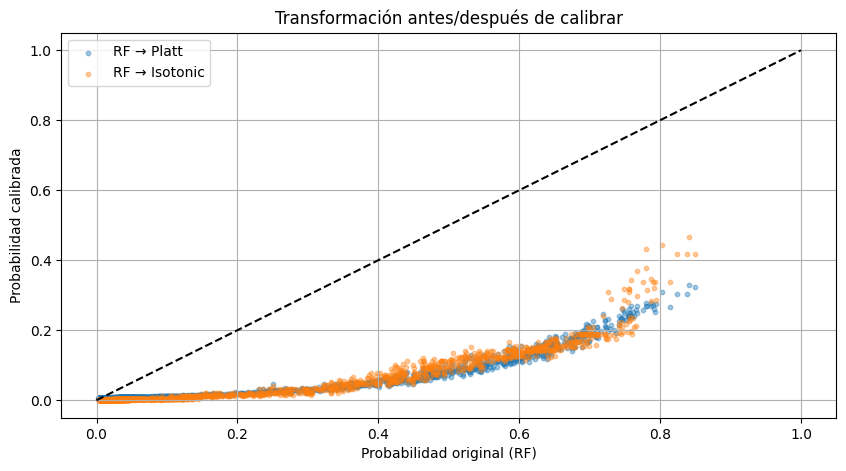

In [55]:
plt.figure(figsize=(10, 5))

plt.scatter(probs_rf, probs_platt, s=10, alpha=0.4, label="RF → Platt")
plt.scatter(probs_rf, probs_iso, s=10, alpha=0.4, label="RF → Isotonic")

plt.plot([0,1],[0,1],'k--') 
plt.xlabel("Probabilidad original (RF)")
plt.ylabel("Probabilidad calibrada")
plt.title("Transformación antes/después de calibrar")
plt.legend()
plt.grid(True)
plt.show()


Este gráfico nos muestra exactamente cómo la calibración transforma las probabilidades. Cada punto es una predicción. En el eje X tenemos la probabilidad original y en el eje Y la probabilidad calibrada.

#### Curvas de calibración (o Reliability Diagrams)

Las curvas de calibración comparan la confianza predicha vs la frecuencia real.
Si la línea está cerca o sobre la diagonal, las probabilidades son buenas, la calibración es perfecta.

c:\Users\cristian.aballay\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\cristian.aballay\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\cristian.aballay\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
c:\Users\cristian.aballay\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


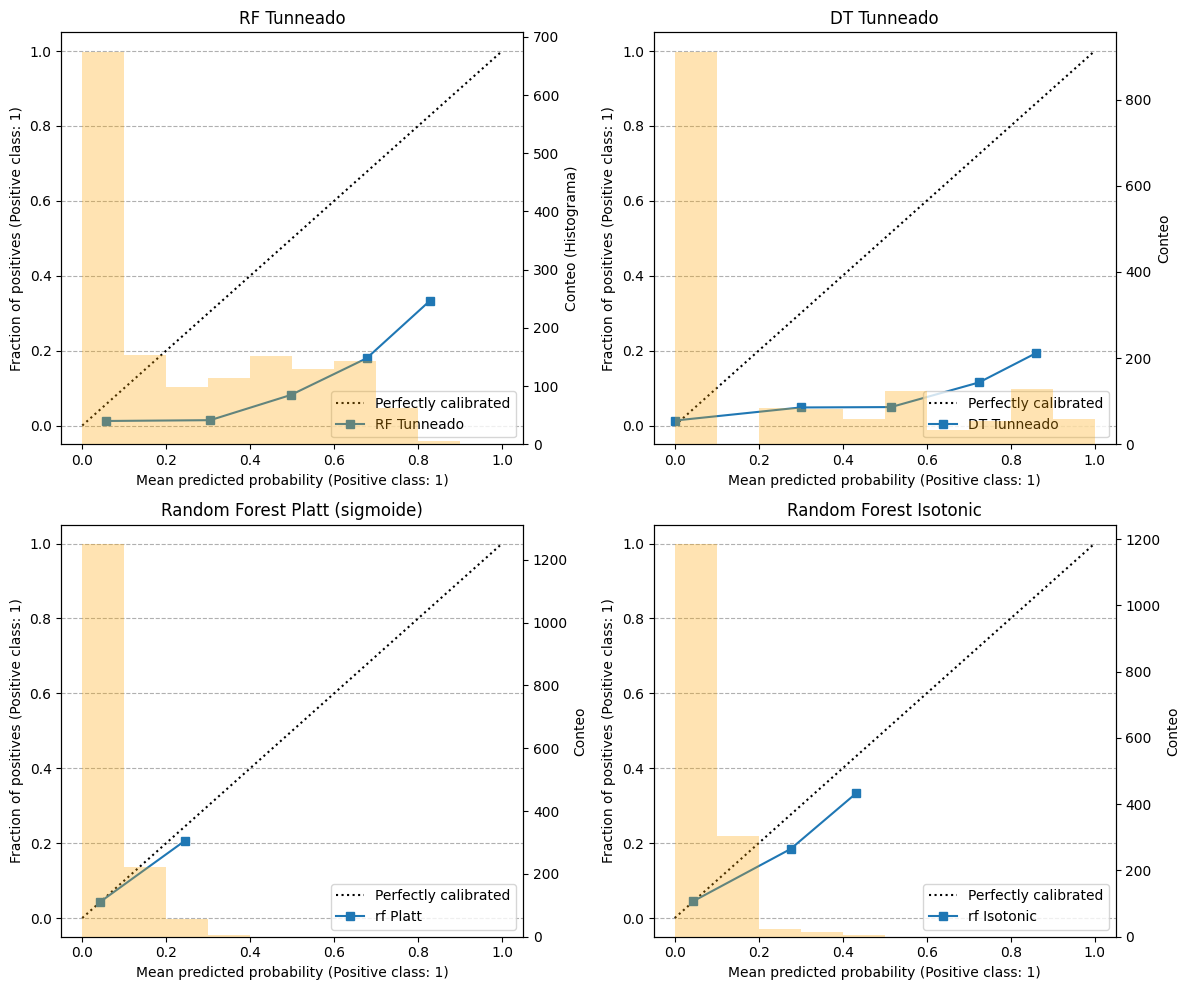

In [57]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Configuración común del histograma ---
hist_params = {'bins': 10, 'range': (0, 1), 'alpha': 0.3, 'color': 'orange', 'edgecolor': 'none'}

# 1. Random Forest (Sin calibrar)
ax1 = axes[0, 0]
CalibrationDisplay.from_estimator(random_forest_classifier_op_tuned, X_test, y_test, name='RF Tunneado', ax=ax1)
# Calculamos probabilidades para el histograma
prob_lr = random_forest_classifier_op_tuned.predict_proba(X_test)[:, 1]
# Creamos eje gemelo
ax1_hist = ax1.twinx()
ax1_hist.hist(prob_lr, **hist_params)
ax1_hist.set_ylabel("Conteo (Histograma)") # Opcional
ax1.set_title("RF Tunneado")
ax1.grid(axis="y", ls='--')


# 2. decision_tree_tuned (Sin calibrar)
ax2 = axes[0, 1]
CalibrationDisplay.from_estimator(decision_tree_tuned, X_test, y_test, name='DT Tunneado', ax=ax2)
prob_rf = decision_tree_tuned.predict_proba(X_test)[:, 1]
ax2_hist = ax2.twinx()
ax2_hist.hist(prob_rf, **hist_params)
ax2_hist.set_ylabel("Conteo")
ax2.set_title("DT Tunneado")
ax2.grid(axis="y", ls='--')


# 3. Random Forest Platt
ax3 = axes[1, 0]
CalibrationDisplay.from_estimator(rf_platt, X_test, y_test, name='rf Platt', ax=ax3)
prob_platt = rf_platt.predict_proba(X_test)[:, 1]
ax3_hist = ax3.twinx()
ax3_hist.hist(prob_platt, **hist_params)
ax3_hist.set_ylabel("Conteo")
ax3.set_title("Random Forest Platt (sigmoide)")
ax3.grid(axis="y", ls='--')


# 4. Random Forest Isotonic
ax4 = axes[1, 1]
CalibrationDisplay.from_estimator(rf_iso, X_test, y_test, name='rf Isotonic', ax=ax4)
prob_iso = rf_iso.predict_proba(X_test)[:, 1]
ax4_hist = ax4.twinx()
ax4_hist.hist(prob_iso, **hist_params)
ax4_hist.set_ylabel("Conteo")
ax4.set_title("Random Forest Isotonic")
ax4.grid(axis="y", ls='--')

plt.tight_layout()
plt.show()

#### ¿Qué revelan estas curvas?

- Random forest (tunneado) es muy confiado (la curva está aplastada en 0 y 1).
- Decision Tree (tunneado) es muy confiado (la curva está aplastada en 0 y 1).
- Random Forest + Platt mejora mucho (queda cerca de la línea perfecta).
- Random Forest + Isotonic mejora muchísimo (queda muy cerca de la línea perfecta).

#### Métricas

El `Brier Score` mide qué tan lejos están las probabilidades de la realidad. Mientras más bajo, mejor.

In [59]:
def resumen_calibracion(y, probs):
    return {
        "Brier": brier_score_loss(y, probs),
        "LogLoss": log_loss(y, probs),
        "Accuracy": accuracy_score(y, (probs >= 0.5))
    }

modelos = {
    "DT Tuneado": decision_tree_tuned.predict_proba(X_test)[:,1],
    "RF Tunneado": random_forest_classifier_op_tuned.predict_proba(X_test)[:,1],
    "Platt": rf_platt.predict_proba(X_test)[:,1],
    "Isotonic": rf_iso.predict_proba(X_test)[:,1],
}

print(pd.DataFrame({k: resumen_calibracion(y_test, v) for k,v in modelos.items()}).T)


c:\Users\cristian.aballay\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
c:\Users\cristian.aballay\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


                Brier   LogLoss  Accuracy
DT Tuneado   0.150851  0.678271  0.762557
RF Tunneado  0.122291  0.366036  0.799739
Platt        0.042521  0.161992  0.951076
Isotonic     0.042843  0.166459  0.951076



## 2. Modelo Naive-Bayes

In [61]:
# Entrenamos un Bayesiano
gnb = make_pipeline(
    StandardScaler(),
    GaussianNB() 
)

gnb.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('gaussiannb', GaussianNB())])

Ahora armamos la versión calibrada:

In [62]:
gnb_iso = make_pipeline(
    StandardScaler(),
    CalibratedClassifierCV(
        estimator=GaussianNB(),
        method='isotonic', cv=5
    )
)
gnb_iso.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('calibratedclassifiercv',
                 CalibratedClassifierCV(cv=5, estimator=GaussianNB(),
                                        method='isotonic'))])

Veamos los resultados:

In [63]:
probs_gnb = gnb.predict_proba(X_test)[:, 1]
probs_iso = gnb_iso.predict_proba(X_test)[:, 1]

#### Histogramas

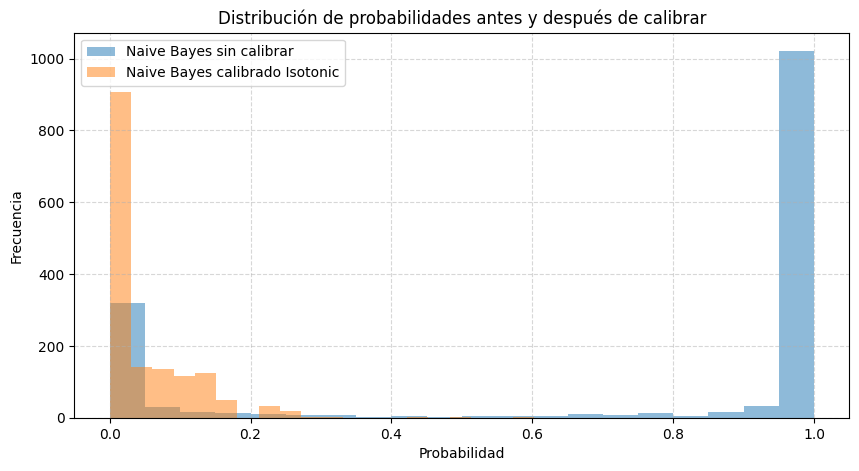

In [64]:
plt.figure(figsize=(10, 5))

# modelo sin calibrar
plt.hist(probs_gnb, bins=20, alpha=0.5, label="Naive Bayes sin calibrar")

# modelo calibrado con Isotonic
plt.hist(probs_iso, bins=20, alpha=0.5, label="Naive Bayes calibrado Isotonic")

plt.xlabel("Probabilidad")
plt.ylabel("Frecuencia")
plt.title("Distribución de probabilidades antes y después de calibrar")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()


### Función para graficar la curva de calibración

Armemos una función para graficar la curva de calibración.

In [65]:
def plot_calibration(y_true, probs_dict, title="Curva de calibración", size=(9,6)):
    plt.figure(figsize=size)
    plt.plot([0, 1], [0, 1], "k--", label="Perfectamente calibrado")

    colors = plt.cm.Dark2.colors 
    
    for i, (name, prob) in enumerate(probs_dict.items()):
        color = colors[i % len(colors)]
        
        frac_pos, mean_pred = calibration_curve(
            y_true, prob, n_bins=5
        )
        brier = brier_score_loss(y_true, prob)
        acc = accuracy_score(y_true, (prob >= 0.5).astype(int))

        plt.plot(mean_pred, frac_pos, marker="o", color=color, linewidth=2,
                 label=f"{name}\nBrier={brier:.3f} | Acc={acc:.3f}")

    plt.xlabel("Probabilidad predicha media")
    plt.ylabel("Fracción de positivos reales")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


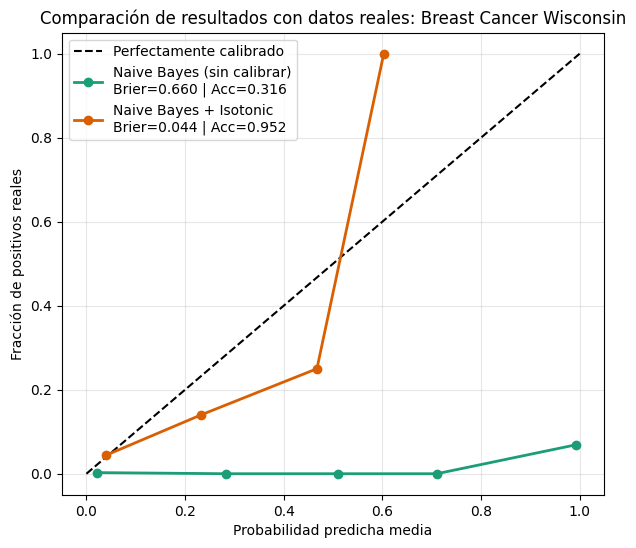

In [66]:
probs = {
    "Naive Bayes (sin calibrar)": gnb.predict_proba(X_test)[:, 1],
    "Naive Bayes + Isotonic": gnb_iso.predict_proba(X_test)[:, 1]
}

plot_calibration(y_test, probs, "Comparación de resultados con datos reales: Breast Cancer Wisconsin", size=(7,6))

#### Métricas

In [67]:
def resumen_calibracion(y, probs):
    return {
        "Brier": brier_score_loss(y, probs),
        "LogLoss": log_loss(y, probs),
        "Accuracy": (probs >= 0.5).mean()
    }

modelos = {
    "NB (sin calibrar)": gnb.predict_proba(X_test)[:,1],
    "Isotonic": gnb_iso.predict_proba(X_test)[:,1],
}

print(pd.DataFrame({k: resumen_calibracion(y_test, v) for k,v in modelos.items()}).T)


                      Brier   LogLoss  Accuracy
NB (sin calibrar)  0.660295  5.735882  0.731246
Isotonic           0.044203  0.172401  0.000652


In [72]:
y_pred = gnb_iso.predict(X_test)
beta = 2
metrics_tree = {
    "name": "Isotonic",
    "Recall": recall_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Accuracy": accuracy_score(y_test, y_pred),    
    "F1": f1_score(y_test, y_pred),
    "F2": fbeta_score(y_test, y_pred, beta=beta)
}

metrics_tree

{'name': 'Isotonic',
 'Recall': 0.013333333333333334,
 'Precision': 1.0,
 'Accuracy': 0.9517286366601435,
 'F1': 0.02631578947368421,
 'F2': 0.016611295681063124}